<a href="https://colab.research.google.com/github/HK25abm/Transformer-Phishing-Detection/blob/main/Final_Model_Comparison_BERT_RoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate evaluate sentencepiece scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [2]:
import gc
import os
import random
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)

In [3]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

CUDA available: True
GPU: Tesla T4


In [4]:
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

train_df.head()

Training: (14000, 6)
Validation: (3000, 6)
Testing: (3000, 6)


,text,label,source,email_type,urls,sample_id
0,Your Approval is Overdue: Access Request for e...,0,Enron,legitimate,0,EMAIL_016400
1,NYTimes.com Article: The Real Wolf This articl...,0,Enron,legitimate,0,EMAIL_004650
2,#xhMSkdThe melody is New! #KnjgJF WATCH >>>,1,CEAS,phishing,0,EMAIL_013860
3,"On Mon, Oct 07, 2002 at 11:05:21PM +0200, Matt...",0,Paper2,legitimate,0,EMAIL_015476
4,massage keeshond livermore pope abet livermore...,1,CEAS,phishing,0,EMAIL_017077


In [5]:
required_columns = {"text", "label"}

for name, frame in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():
    missing = required_columns - set(frame.columns)

    if missing:
        raise ValueError(
            f"{name} is missing columns: {missing}"
        )

In [6]:
def prepare_split(frame):
    frame = frame.copy()

    frame = frame.dropna(
        subset=["text", "label"]
    )

    frame["text"] = frame["text"].astype(str)
    frame["label"] = frame["label"].astype(int)

    frame = frame[
        frame["label"].isin([0, 1])
    ]

    frame = frame.reset_index(drop=True)

    return frame


train_df = prepare_split(train_df)
val_df = prepare_split(val_df)
test_df = prepare_split(test_df)

In [7]:
for name, frame in {
    "Training": train_df,
    "Validation": val_df,
    "Testing": test_df
}.items():
    print(f"\n{name}:")
    print(frame["label"].value_counts())


Training:
label
0    7000
1    7000
Name: count, dtype: int64

Validation:
label
1    1500
0    1500
Name: count, dtype: int64

Testing:
label
0    1500
1    1500
Name: count, dtype: int64


In [8]:
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "Train–validation overlap:",
    len(train_texts & val_texts)
)

print(
    "Train–test overlap:",
    len(train_texts & test_texts)
)

print(
    "Validation–test overlap:",
    len(val_texts & test_texts)
)

Train–validation overlap: 0
Train–test overlap: 0
Validation–test overlap: 0


In [9]:
val_df = val_df[
    ~val_df["text"].isin(train_texts)
].reset_index(drop=True)

test_df = test_df[
    ~test_df["text"].isin(
        train_texts | set(val_df["text"])
    )
].reset_index(drop=True)

In [10]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

In [11]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length=256
    ):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        encoding = self.tokenizer(
            self.texts[index],
            truncation=True,
            max_length=self.max_length
        )

        encoding["labels"] = self.labels[index]

        return encoding

In [12]:
def compute_metrics(eval_prediction):
    logits, labels = eval_prediction

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions
        ),
        "precision": precision_score(
            labels,
            predictions,
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            predictions,
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            predictions,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            labels,
            probabilities[:, 1]
        )
    }

In [13]:
MODEL_CONFIGS = {
    "BERT": "bert-base-uncased",
    "RoBERTa": "roberta-base",
    "DeBERTa": "microsoft/deberta-v3-base"
}

In [14]:
def train_and_evaluate_model(
    model_display_name,
    model_checkpoint,
    max_length=256
):
    print("=" * 70)
    print(f"Starting {model_display_name}")
    print(f"Checkpoint: {model_checkpoint}")
    print("=" * 70)

    tokenizer = AutoTokenizer.from_pretrained(
        model_checkpoint,
        use_fast=True
    )

    train_dataset = EmailDataset(
        train_df["text"],
        train_df["label"],
        tokenizer,
        max_length=max_length
    )

    validation_dataset = EmailDataset(
        val_df["text"],
        val_df["label"],
        tokenizer,
        max_length=max_length
    )

    test_dataset = EmailDataset(
        test_df["text"],
        test_df["label"],
        tokenizer,
        max_length=max_length
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=2,
        id2label={
            0: "Legitimate",
            1: "Phishing"
        },
        label2id={
            "Legitimate": 0,
            "Phishing": 1
        }
    )

    output_directory = (
        f"./final_models/"
        f"{model_display_name.lower()}"
    )

    training_args = TrainingArguments(
        output_dir=output_directory,

        learning_rate=2e-5,

        per_device_train_batch_size=8,
        gradient_accumulation_steps=2,

        per_device_eval_batch_size=16,

        num_train_epochs=3,
        weight_decay=0.01,

        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,

        fp16=torch.cuda.is_available(),

        report_to="none",
        seed=SEED,
        data_seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=validation_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    start_time = time.time()

    training_output = trainer.train()

    training_time = time.time() - start_time

    test_output = trainer.predict(
        test_dataset
    )

    test_logits = test_output.predictions
    y_true = test_output.label_ids

    test_probabilities = torch.softmax(
        torch.tensor(test_logits),
        dim=1
    ).numpy()

    y_pred = np.argmax(
        test_probabilities,
        axis=1
    )

    metrics = {
        "Model": model_display_name,
        "Checkpoint": model_checkpoint,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            test_probabilities[:, 1]
        ),
        "Training Time Seconds": training_time,
        "Best Checkpoint":
            trainer.state.best_model_checkpoint
    }

    os.makedirs(
        "./final_outputs",
        exist_ok=True
    )

    safe_name = model_display_name.lower()

    report = classification_report(
        y_true,
        y_pred,
        target_names=[
            "Legitimate",
            "Phishing"
        ],
        digits=4,
        output_dict=True
    )

    pd.DataFrame(report).transpose().to_csv(
        f"./final_outputs/"
        f"{safe_name}_classification_report.csv"
    )

    prediction_frame = test_df.copy()

    prediction_frame["predicted_label"] = y_pred
    prediction_frame["legitimate_probability"] = (
        test_probabilities[:, 0]
    )
    prediction_frame["phishing_probability"] = (
        test_probabilities[:, 1]
    )

    prediction_frame.to_csv(
        f"./final_outputs/"
        f"{safe_name}_test_predictions.csv",
        index=False
    )

    confusion = confusion_matrix(
        y_true,
        y_pred
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion,
        display_labels=[
            "Legitimate",
            "Phishing"
        ]
    ).plot(values_format="d")

    plt.title(
        f"{model_display_name} Confusion Matrix"
    )
    plt.tight_layout()
    plt.savefig(
        f"./final_outputs/"
        f"{safe_name}_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    RocCurveDisplay.from_predictions(
        y_true,
        test_probabilities[:, 1],
        name=model_display_name
    )

    plt.title(
        f"{model_display_name} ROC Curve"
    )
    plt.tight_layout()
    plt.savefig(
        f"./final_outputs/"
        f"{safe_name}_roc_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    log_history = pd.DataFrame(
        trainer.state.log_history
    )

    log_history.to_csv(
        f"./final_outputs/"
        f"{safe_name}_training_log.csv",
        index=False
    )

    trainer.save_model(
        f"./final_models/{safe_name}/best_model"
    )

    tokenizer.save_pretrained(
        f"./final_models/{safe_name}/best_model"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=[
                "Legitimate",
                "Phishing"
            ],
            digits=4
        )
    )

    print(metrics)

    del model
    del trainer
    del train_dataset
    del validation_dataset
    del test_dataset

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics

Starting BERT
Checkpoint: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.168616,0.082193,0.982000,0.988514,0.975333,0.981879,0.998327
2,0.060110,0.088421,0.979000,0.966862,0.992000,0.979269,0.998538
3,0.019599,0.093309,0.985333,0.989247,0.981333,0.985274,0.998537


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

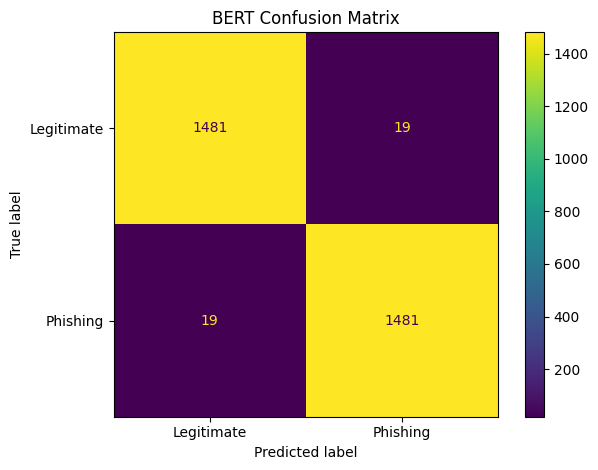

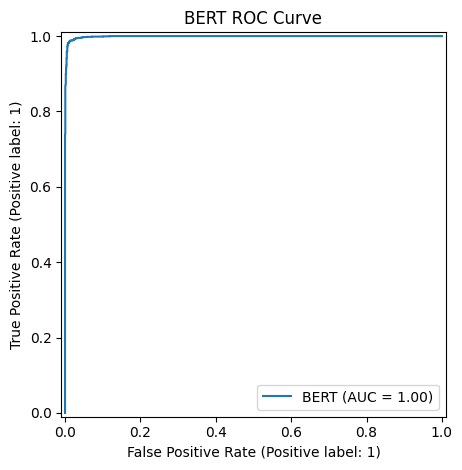

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

  Legitimate     0.9873    0.9873    0.9873      1500
    Phishing     0.9873    0.9873    0.9873      1500

    accuracy                         0.9873      3000
   macro avg     0.9873    0.9873    0.9873      3000
weighted avg     0.9873    0.9873    0.9873      3000

{'Model': 'BERT', 'Checkpoint': 'bert-base-uncased', 'Accuracy': 0.9873333333333333, 'Precision': 0.9873333333333333, 'Recall': 0.9873333333333333, 'F1-score': 0.9873333333333333, 'ROC-AUC': np.float64(0.9989073333333333), 'Training Time Seconds': 732.1448895931244, 'Best Checkpoint': './final_models/bert/checkpoint-2625'}


In [15]:
bert_metrics = train_and_evaluate_model(
    model_display_name="BERT",
    model_checkpoint="bert-base-uncased",
    max_length=256
)

Starting RoBERTa
Checkpoint: roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.192244,0.060512,0.988000,0.989305,0.986667,0.987984,0.998881
2,0.060668,0.056628,0.988667,0.992608,0.984667,0.988621,0.998813
3,0.027377,0.073809,0.988333,0.993931,0.982667,0.988267,0.999100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

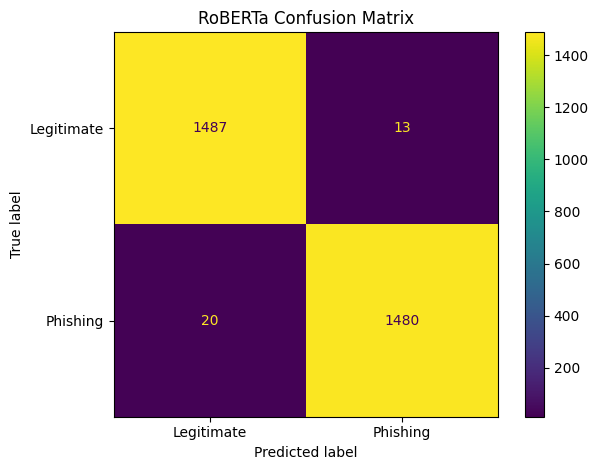

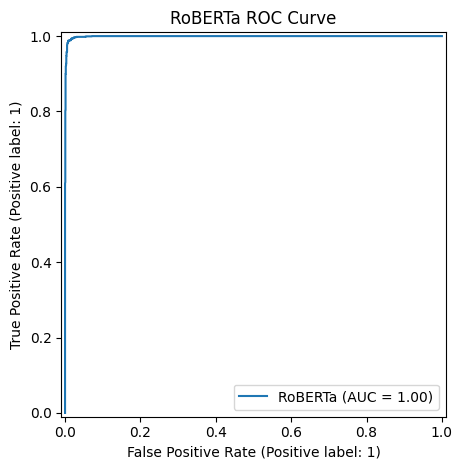

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

  Legitimate     0.9867    0.9913    0.9890      1500
    Phishing     0.9913    0.9867    0.9890      1500

    accuracy                         0.9890      3000
   macro avg     0.9890    0.9890    0.9890      3000
weighted avg     0.9890    0.9890    0.9890      3000

{'Model': 'RoBERTa', 'Checkpoint': 'roberta-base', 'Accuracy': 0.989, 'Precision': 0.9912926992632284, 'Recall': 0.9866666666666667, 'F1-score': 0.9889742733043769, 'ROC-AUC': np.float64(0.9990804444444444), 'Training Time Seconds': 695.5163798332214, 'Best Checkpoint': './final_models/roberta/checkpoint-1750'}


In [16]:
roberta_metrics = train_and_evaluate_model(
    model_display_name="RoBERTa",
    model_checkpoint="roberta-base",
    max_length=256
)

In [18]:
bert_metrics = {
    "Model": "BERT",
    "Accuracy": bert_accuracy,
    "Precision": bert_precision,
    "Recall": bert_recall,
    "F1-score": bert_f1,
    "ROC-AUC": bert_auc,
    "Training Time Seconds": bert_training_time
}

bert_results = pd.DataFrame([bert_metrics])

bert_results.to_csv(
    "bert_results.csv",
    index=False
)

bert_results

NameError: name 'bert_accuracy' is not defined

In [20]:
print([v for v in globals() if "bert" in v.lower()])

['bert_metrics', 'roberta_metrics']


In [21]:
print(bert_metrics)

{'Model': 'BERT', 'Checkpoint': 'bert-base-uncased', 'Accuracy': 0.9873333333333333, 'Precision': 0.9873333333333333, 'Recall': 0.9873333333333333, 'F1-score': 0.9873333333333333, 'ROC-AUC': np.float64(0.9989073333333333), 'Training Time Seconds': 732.1448895931244, 'Best Checkpoint': './final_models/bert/checkpoint-2625'}


In [22]:
print(roberta_metrics)

{'Model': 'RoBERTa', 'Checkpoint': 'roberta-base', 'Accuracy': 0.989, 'Precision': 0.9912926992632284, 'Recall': 0.9866666666666667, 'F1-score': 0.9889742733043769, 'ROC-AUC': np.float64(0.9990804444444444), 'Training Time Seconds': 695.5163798332214, 'Best Checkpoint': './final_models/roberta/checkpoint-1750'}


In [23]:
import pandas as pd

bert_results = pd.DataFrame([bert_metrics])

bert_results.to_csv(
    "bert_results.csv",
    index=False
)

bert_results

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint
0,BERT,bert-base-uncased,0.987333,0.987333,0.987333,0.987333,0.998907,732.14489,./final_models/bert/checkpoint-2625


In [24]:
roberta_results = pd.DataFrame([roberta_metrics])

roberta_results.to_csv(
    "roberta_results.csv",
    index=False
)

roberta_results

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint
0,RoBERTa,roberta-base,0.989,0.991293,0.986667,0.988974,0.99908,695.51638,./final_models/roberta/checkpoint-1750


In [25]:
comparison_df = pd.concat(
    [bert_results, roberta_results],
    ignore_index=True
)

comparison_df

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint
0,BERT,bert-base-uncased,0.987333,0.987333,0.987333,0.987333,0.998907,732.14489,./final_models/bert/checkpoint-2625
1,RoBERTa,roberta-base,0.989000,0.991293,0.986667,0.988974,0.999080,695.51638,./final_models/roberta/checkpoint-1750


In [26]:
comparison_df.to_csv(
    "bert_roberta_comparison.csv",
    index=False
)

In [27]:
from google.colab import files

files.download("bert_results.csv")
files.download("roberta_results.csv")
files.download("bert_roberta_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import os

os.makedirs("BERT_RoBERTa_Results", exist_ok=True)

In [29]:
import shutil
import os

files_to_copy = [
    "bert_results.csv",
    "roberta_results.csv",
    "bert_roberta_comparison.csv",

    "bert_predictions.csv",
    "roberta_predictions.csv",

    "bert_confusion_matrix.png",
    "roberta_confusion_matrix.png",

    "bert_roc_curve.png",
    "roberta_roc_curve.png",

    "bert_training_log.csv",
    "roberta_training_log.csv"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, "BERT_RoBERTa_Results/")
    else:
        print(f"❌ Missing: {file}")

❌ Missing: bert_predictions.csv
❌ Missing: roberta_predictions.csv
❌ Missing: bert_confusion_matrix.png
❌ Missing: roberta_confusion_matrix.png
❌ Missing: bert_roc_curve.png
❌ Missing: roberta_roc_curve.png
❌ Missing: bert_training_log.csv
❌ Missing: roberta_training_log.csv


In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=bert_cm,
    display_labels=["Legitimate","Phishing"]
).plot(values_format="d")

plt.savefig("bert_confusion_matrix.png", dpi=300)
plt.show()

NameError: name 'bert_cm' is not defined

In [31]:
bert_metrics
roberta_metrics

{'Model': 'RoBERTa',
 'Checkpoint': 'roberta-base',
 'Accuracy': 0.989,
 'Precision': 0.9912926992632284,
 'Recall': 0.9866666666666667,
 'F1-score': 0.9889742733043769,
 'ROC-AUC': np.float64(0.9990804444444444),
 'Training Time Seconds': 695.5163798332214,
 'Best Checkpoint': './final_models/roberta/checkpoint-1750'}

In [32]:
import os
import pandas as pd

os.makedirs("BERT_RoBERTa_Results", exist_ok=True)

bert_results = pd.DataFrame([bert_metrics])
roberta_results = pd.DataFrame([roberta_metrics])

bert_results.to_csv(
    "BERT_RoBERTa_Results/bert_results.csv",
    index=False
)

roberta_results.to_csv(
    "BERT_RoBERTa_Results/roberta_results.csv",
    index=False
)

comparison_df = pd.concat(
    [bert_results, roberta_results],
    ignore_index=True
)

comparison_df.to_csv(
    "BERT_RoBERTa_Results/bert_roberta_comparison.csv",
    index=False
)

comparison_df

,Model,Checkpoint,Accuracy,Precision,Recall,F1-score,ROC-AUC,Training Time Seconds,Best Checkpoint
0,BERT,bert-base-uncased,0.987333,0.987333,0.987333,0.987333,0.998907,732.14489,./final_models/bert/checkpoint-2625
1,RoBERTa,roberta-base,0.989000,0.991293,0.986667,0.988974,0.999080,695.51638,./final_models/roberta/checkpoint-1750


In [33]:
import os

for root, dirs, files in os.walk("."):
    for filename in files:
        if "bert" in filename.lower() or "roberta" in filename.lower():
            print(os.path.join(root, filename))

./roberta_results.csv
./bert_results.csv
./bert_roberta_comparison.csv
./final_outputs/bert_roc_curve.png
./final_outputs/roberta_confusion_matrix.png
./final_outputs/roberta_training_log.csv
./final_outputs/bert_classification_report.csv
./final_outputs/bert_training_log.csv
./final_outputs/roberta_classification_report.csv
./final_outputs/roberta_test_predictions.csv
./final_outputs/roberta_roc_curve.png
./final_outputs/bert_test_predictions.csv
./final_outputs/bert_confusion_matrix.png
./BERT_RoBERTa_Results/roberta_results.csv
./BERT_RoBERTa_Results/bert_results.csv
./BERT_RoBERTa_Results/bert_roberta_comparison.csv


In [34]:
import shutil

possible_files = [
    "./final_outputs/bert_test_predictions.csv",
    "./final_outputs/roberta_test_predictions.csv",
    "./final_outputs/bert_confusion_matrix.png",
    "./final_outputs/roberta_confusion_matrix.png",
    "./final_outputs/bert_roc_curve.png",
    "./final_outputs/roberta_roc_curve.png",
    "./final_outputs/bert_training_log.csv",
    "./final_outputs/roberta_training_log.csv",
    "./final_outputs/bert_classification_report.csv",
    "./final_outputs/roberta_classification_report.csv"
]

for source in possible_files:
    if os.path.exists(source):
        shutil.copy(source, "BERT_RoBERTa_Results/")
        print("Copied:", source)
    else:
        print("Not found:", source)

Copied: ./final_outputs/bert_test_predictions.csv
Copied: ./final_outputs/roberta_test_predictions.csv
Copied: ./final_outputs/bert_confusion_matrix.png
Copied: ./final_outputs/roberta_confusion_matrix.png
Copied: ./final_outputs/bert_roc_curve.png
Copied: ./final_outputs/roberta_roc_curve.png
Copied: ./final_outputs/bert_training_log.csv
Copied: ./final_outputs/roberta_training_log.csv
Copied: ./final_outputs/bert_classification_report.csv
Copied: ./final_outputs/roberta_classification_report.csv


In [35]:
if os.path.exists("./final_models/bert/best_model"):
    shutil.copytree(
        "./final_models/bert/best_model",
        "BERT_RoBERTa_Results/bert_model",
        dirs_exist_ok=True
    )

if os.path.exists("./final_models/roberta/best_model"):
    shutil.copytree(
        "./final_models/roberta/best_model",
        "BERT_RoBERTa_Results/roberta_model",
        dirs_exist_ok=True
    )

In [36]:
shutil.make_archive(
    "BERT_RoBERTa_Results",
    "zip",
    "BERT_RoBERTa_Results"
)

'/content/BERT_RoBERTa_Results.zip'

In [37]:
from google.colab import files

files.download("BERT_RoBERTa_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>